In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/clean_nav_history.csv")
perf = pd.read_csv("../data/processed/clean_scheme_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"])

In [14]:
from scipy.stats import linregress

In [2]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

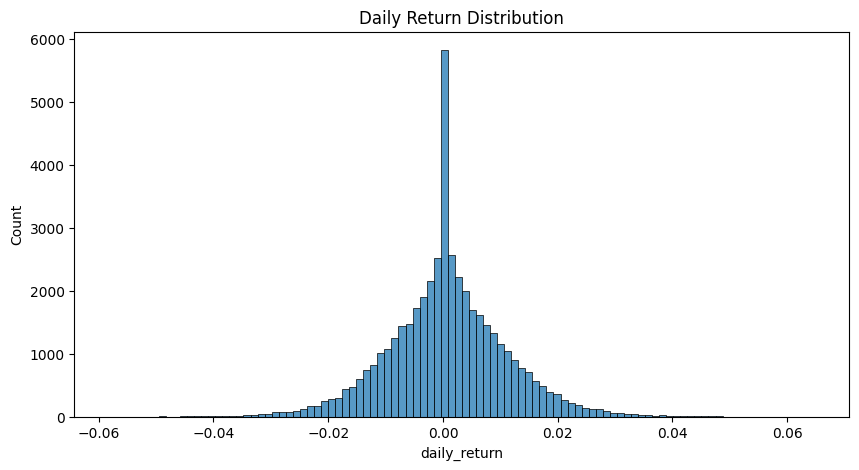

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(nav["daily_return"].dropna(), bins=100)
plt.title("Daily Return Distribution")
plt.show()

In [4]:
def calculate_cagr(df, years):

    results = []

    for fund in df["amfi_code"].unique():

        temp = df[
            df["amfi_code"] == fund
        ]

        end_date = temp["date"].max()

        start_date = (
            end_date -
            pd.DateOffset(years=years)
        )

        temp = temp[
            temp["date"] >= start_date
        ]

        if len(temp) > 10:

            start_nav = temp.iloc[0]["nav"]

            end_nav = temp.iloc[-1]["nav"]

            cagr = (
                (end_nav/start_nav)
                **(1/years)
            ) - 1

            results.append(
                [fund,cagr]
            )

    return pd.DataFrame(
        results,
        columns=[
            "amfi_code",
            f"CAGR_{years}Y"
        ]
    )

In [5]:
cagr1 = calculate_cagr(nav,1)

cagr3 = calculate_cagr(nav,3)

cagr5 = calculate_cagr(nav,5)

In [6]:
cagr_table = (
    cagr1
    .merge(cagr3,on="amfi_code",how="outer")
    .merge(cagr5,on="amfi_code",how="outer")
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [7]:
RF = 0.065

In [8]:
def sharpe_ratio(x):

    annual_return = (
        x.mean()*252
    )

    annual_vol = (
        x.std()*np.sqrt(252)
    )

    return (
        annual_return - RF
    ) / annual_vol

In [9]:
sharpe = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .apply(sharpe_ratio)
       .reset_index()
)

sharpe.columns = [
    "amfi_code",
    "sharpe_ratio"
]

sharpe.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [10]:
def sortino_ratio(x):

    downside = x[x < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        x.mean()*252
    )

    return (
        annual_return - RF
    ) / downside_std

In [11]:
sortino = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .apply(sortino_ratio)
       .reset_index()
)

sortino.columns = [
    "amfi_code",
    "sortino_ratio"
]

sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [12]:
benchmark = (
    nav.groupby("date")
       ["daily_return"]
       .mean()
       .reset_index()
)

benchmark.columns = [
    "date",
    "benchmark_return"
]

In [13]:
results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    temp = temp.merge(
        benchmark,
        on="date"
    )

    temp = temp.dropna()

    if len(temp) > 100:

        slope, intercept, r, p, se = (
            linregress(
                temp["benchmark_return"],
                temp["daily_return"]
            )
        )

        alpha = intercept * 252

        beta = slope

        results.append(
            [fund,alpha,beta]
        )

alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

NameError: name 'linregress' is not defined

In [15]:
results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    temp = temp.merge(
        benchmark,
        on="date"
    )

    temp = temp.dropna()

    if len(temp) > 100:

        slope, intercept, r, p, se = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        results.append(
            [fund, alpha, beta]
        )

alpha_beta = pd.DataFrame(
    results,
    columns=["amfi_code","alpha","beta"]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [16]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [17]:
dd_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
    ) - 1

    dd_results.append(
        [
            fund,
            temp["drawdown"].min()
        ]
    )

dd = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [18]:
score = (
    sharpe
    .merge(alpha_beta)
    .merge(dd)
    .merge(
        perf[
            [
                "amfi_code",
                "return_3yr_pct",
                "expense_ratio_pct"
            ]
        ]
    )
)

score.head()

,amfi_code,sharpe_ratio,alpha,beta,max_drawdown,return_3yr_pct,expense_ratio_pct
0,100016,-0.201517,-0.089699,0.788441,-0.247344,14.84,1.55
1,100025,-0.567095,0.033199,0.060713,-0.043083,7.37,0.56
2,100033,1.093699,0.114423,0.991590,-0.162172,16.58,1.38
3,101206,1.027213,0.097443,0.737015,-0.112916,13.78,1.60
4,101207,0.162661,-0.350741,2.878184,-0.354469,22.38,1.53


In [19]:
score["r1"] = score["return_3yr_pct"].rank()

score["r2"] = score["sharpe_ratio"].rank()

score["r3"] = score["alpha"].rank()

score["r4"] = (
    score["expense_ratio_pct"]
    .rank(ascending=False)
)

score["r5"] = (
    score["max_drawdown"]
    .rank(ascending=False)
)

score.head()

,amfi_code,sharpe_ratio,alpha,beta,max_drawdown,return_3yr_pct,expense_ratio_pct,r1,r2,r3,r4,r5
0,100016,-0.201517,-0.089699,0.788441,-0.247344,14.84,1.55,25.0,6.0,9.0,9.0,34.0
1,100025,-0.567095,0.033199,0.060713,-0.043083,7.37,0.56,5.0,2.0,19.0,39.0,4.0
2,100033,1.093699,0.114423,0.991590,-0.162172,16.58,1.38,31.0,34.0,37.0,24.0,20.0
3,101206,1.027213,0.097443,0.737015,-0.112916,13.78,1.60,19.0,32.0,34.0,4.5,9.0
4,101207,0.162661,-0.350741,2.878184,-0.354469,22.38,1.53,38.0,13.0,1.0,12.5,38.0


In [20]:
score["fund_score"] = (

      score["r1"]*0.30
    + score["r2"]*0.25
    + score["r3"]*0.20
    + score["r4"]*0.15
    + score["r5"]*0.10

)

score = score.sort_values(
    "fund_score",
    ascending=False
)

score.head(10)

,amfi_code,sharpe_ratio,alpha,beta,max_drawdown,return_3yr_pct,expense_ratio_pct,r1,r2,r3,r4,r5,fund_score
25,120505,1.180101,0.102647,1.194815,-0.181885,18.08,1.36,33.0,36.0,36.0,26.0,25.0,32.500
2,100033,1.093699,0.114423,0.991590,-0.162172,16.58,1.38,31.0,34.0,37.0,24.0,20.0,30.800
30,120843,1.306744,0.102645,1.068746,-0.129740,15.65,1.45,30.0,39.0,35.0,19.0,13.0,29.900
34,148567,1.448291,0.181968,0.557134,-0.112657,14.81,1.46,24.0,40.0,40.0,18.0,8.0,28.700
38,149323,1.132122,0.087723,1.120482,-0.172481,17.16,1.61,32.0,35.0,32.0,3.0,22.0,27.400
21,119598,0.945308,-0.088127,2.457369,-0.287060,23.39,1.43,40.0,27.0,10.0,20.0,36.0,27.350
24,120504,1.026524,0.115994,0.606529,-0.125883,14.41,0.80,21.0,31.0,38.0,29.0,12.0,27.200
39,149324,0.949796,-0.051278,2.214804,-0.311719,20.08,1.52,35.0,28.0,12.0,14.5,37.0,25.775
19,119551,1.208267,0.141513,0.562931,-0.150124,12.36,1.54,15.0,37.0,39.0,10.5,17.0,24.825
16,119094,0.998231,0.016867,1.520896,-0.209609,15.18,1.38,26.0,30.0,14.0,24.0,28.0,24.500


In [21]:
score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [22]:
top5 = (
    score.head(5)
    ["amfi_code"]
    .tolist()
)

top5

[120505, 100033, 120843, 148567, 149323]

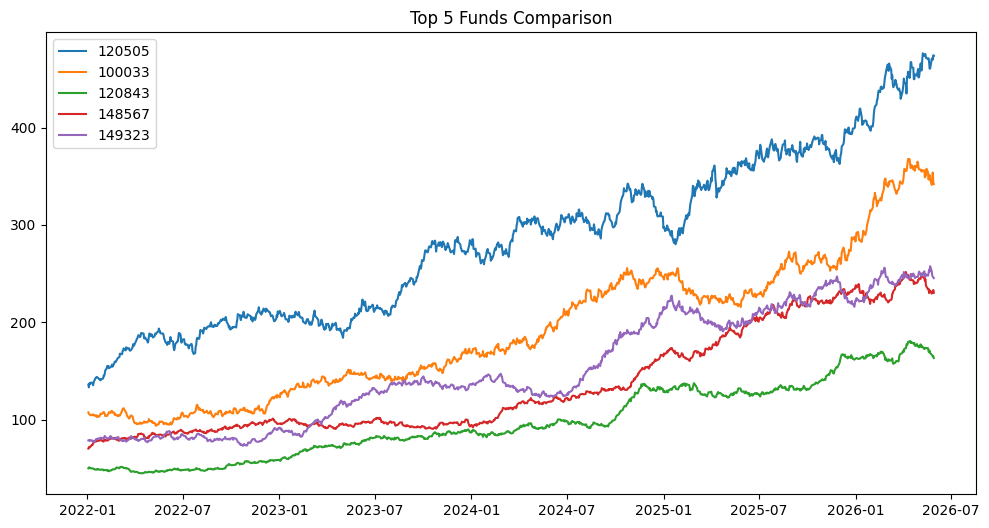

In [23]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds Comparison"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()